In [8]:


from typing import TypedDict
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
import os


load_dotenv()

True

In [9]:
def get_groq_llm():
    return ChatOpenAI(
        model= "openai/gpt-oss-120b",
        base_url= "https://api.groq.com/openai/v1",
        api_key= os.getenv("GROQ_API_KEY"),
        max_tokens= 1000
    )

llm= get_groq_llm()

NameError: name 'ChatOpenAI' is not defined

In [10]:
class LLMState(TypedDict):
    question: str
    answer: str

In [11]:
def chat_llm(state: LLMState):

    question= state['question']

    ##prompt:
    prompt= f'Answer the following Question {question}'

    answer= llm.invoke(prompt).content
    
    state['answer']= answer

    return state

In [12]:
graph= StateGraph(LLMState)

## add nodes

graph.add_node('chat_llm',chat_llm)

In [13]:
## add edges

graph.add_edge(START,'chat_llm')
graph.add_edge('chat_llm', END)

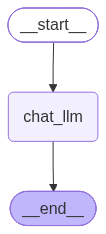

In [19]:
workflow= graph.compile()

workflow

In [20]:
intial_state= {'question':'How far is the moon from earth'}

final_state= workflow.invoke(intial_state)

print(final_state)

{'question': 'How far is the moon from earth', 'answer': 'The Moon orbits Earth at an average distance of **about\u202f384\u202f400\u202fkilometers (≈238\u202f900\u202fmiles)**.\n\n- **Closest approach (perigee):** ~363\u202f300\u202fkm (≈225\u202f600\u202fmi)  \n- **Furthest point (apogee):** ~405\u202f500\u202fkm (≈252\u202f000\u202fmi)\n\nThese values are averages; the actual distance varies slightly from orbit to orbit due to the Moon’s elliptical trajectory.'}


In [21]:
print(final_state['answer'])

The Moon orbits Earth at an average distance of **about 384 400 kilometers (≈238 900 miles)**.

- **Closest approach (perigee):** ~363 300 km (≈225 600 mi)  
- **Furthest point (apogee):** ~405 500 km (≈252 000 mi)

These values are averages; the actual distance varies slightly from orbit to orbit due to the Moon’s elliptical trajectory.


In [22]:
intial_state= {'question':'okay great but how far from Sun?'}

final_state= workflow.invoke(intial_state)

In [24]:
print(final_state['answer'])

The short answer is **about 1 Astronomical Unit (AU)** – roughly **149.6 million kilometres (≈ 93 million miles)** – which is the average distance between the Earth and the Sun.

Because every planet’s orbit is slightly elliptical, the actual Sun‑Earth distance varies a bit over the course of a year:

| Point in Earth’s orbit | Distance from Sun | Approx. value |
|------------------------|-------------------|---------------|
| **Perihelion** (closest, early January) | 147.1 million km | 0.983 AU |
| **Aphelion** (farthest, early July) | 152.1 million km | 1.017 AU |

If you were asking about the distance to **another object** (e.g., another planet or a spacecraft), here are the average orbital distances for the eight planets in the Solar System, expressed both in astronomical units and kilometres:

| Planet | Average distance (AU) | Approx. distance (million km) |
|--------|----------------------|-------------------------------|
| Mercury | 0.39 | 57.9 |
| Venus   | 0.72 | 108.2 |
| Ea

In [27]:
import prompt_inspector
prompt_inspector.inspect()

INFO:prompt-inspector:OpenAI client auto-patched successfully!


In [28]:
import prompt_inspector
prompt_inspector.inspect()

INFO:prompt-inspector:OpenAI client auto-patched successfully!
